# Replikasi Klasifikasi Penyakit Daun Tomat: SVM vs KNN

Notebook ini menjalankan project secara step-by-step agar setiap tahap eksperimen dapat dibaca, dieksekusi ulang, dan diperiksa hasilnya.

Metode yang digunakan:

- Support Vector Machine (SVM)
- K-Nearest Neighbor (KNN)

Fitur citra yang diekstraksi:

- Color Histogram RGB
- Color Histogram HSV
- GLCM texture features
- LBP texture features

## 1. Setup Environment

Jalankan notebook ini dari folder project `tomato-leaf-svm-knn`. Jika dependency belum terpasang, jalankan dulu di terminal:

```bash
python3.12 -m venv .venv
source .venv/bin/activate
python -m pip install -r requirements.txt
```

In [1]:
from pathlib import Path
import sys

# Jika notebook dibuka dari folder notebooks, pindahkan konteks ke project root.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
PROJECT_ROOT

PosixPath('/Users/ramadhanial-qadri/Documents/My_File/MILKOM/Komputer Visual/SVM/tomato-leaf-svm-knn')

In [2]:
import pandas as pd
from IPython.display import Markdown, display, Image

from src import config
from src.analyze_dataset import analyze_dataset
from src.prepare_dataset import prepare_dataset
from src.feature_extraction import extract_features
from src.train_svm import train_svm
from src.train_knn import train_knn
from src.evaluate_models import evaluate_models
from src.compare_results import compare_results

print("Dataset directory:", config.DATASET_DIR)
print("Target classes:", config.TARGET_CLASSES)
print("Image size:", config.IMAGE_SIZE)
print("Random state:", config.RANDOM_STATE)

Dataset directory: data/raw
Target classes: ['Early Blight', 'Healthy', 'Late Blight', 'Mosaic Virus', 'Yellow Leaf Curl Virus']
Image size: (128, 128)
Random state: 42


## 2. Analisis Jurnal

Ringkasan jurnal sudah dibuat di `reports/analisis_jurnal.md`. Cell berikut menampilkannya di notebook.

In [3]:
display(Markdown((PROJECT_ROOT / "reports/analisis_jurnal.md").read_text(encoding="utf-8")))

# Analisis Jurnal

Judul: **Comparison of Tomato Leaf Disease Classification Accuracy Using Support Vector Machine and K-Nearest Neighbor Methods**

Sumber lokal: `References/12195-Article Text-11112-1-10-20230407.pdf`  
Publikasi: Sinkron: Jurnal dan Penelitian Teknik Informatika, Vol. 7 No. 2, April 2023  
DOI: `https://doi.org/10.33395/sinkron.v8i2.12195`

## a. Tujuan Penelitian

Penelitian bertujuan membandingkan akurasi klasifikasi penyakit daun tomat menggunakan dua metode machine learning klasik: Support Vector Machine (SVM) dan K-Nearest Neighbor (KNN). Fokus utamanya adalah mencari metode dengan hasil klasifikasi terbaik pada citra daun tomat.

## b. Permasalahan Penelitian

Penyakit daun tomat dapat diamati dari perubahan warna, tekstur, dan karakteristik visual daun. Pemeriksaan manual oleh petani membutuhkan waktu, berisiko keliru, dan dapat menyebabkan pemilihan penanganan penyakit yang tidak tepat. Karena itu, diperlukan sistem klasifikasi berbasis citra yang lebih konsisten.

## c. Dataset Yang Digunakan

Dataset berasal dari Kaggle dan berisi citra daun tomat. Jurnal menggunakan total 5000 gambar, terdiri dari 5 kelas dengan 1000 gambar per kelas. Pembagian data yang dilaporkan adalah 800 gambar training dan 200 gambar testing untuk setiap kelas, sehingga totalnya 4000 data training dan 1000 data testing.

## d. Kelas Yang Digunakan

Lima kelas pada jurnal adalah:

1. Early Blight
2. Healthy
3. Late Blight
4. Mosaic Virus
5. Yellow Leaf Curl Virus

## e. Metode Yang Digunakan

Metode klasifikasi yang dibandingkan:

- Support Vector Machine (SVM)
- K-Nearest Neighbor (KNN)

Jurnal menyebut penggunaan Orange sebagai alat eksperimen. SVM diposisikan sebagai classifier berbasis hyperplane, sedangkan KNN menggunakan kedekatan data berdasarkan jarak Euclidean.

## f. Alur Penelitian

Alur penelitian yang dijelaskan:

1. Dataset citra daun tomat dikumpulkan.
2. Data melalui tahap preprocessing.
3. Data diklasifikasikan menggunakan SVM.
4. Data diklasifikasikan menggunakan KNN.
5. Model dievaluasi menggunakan variasi cross validation.
6. Hasil SVM dan KNN dibandingkan untuk menentukan metode terbaik.

## g. Evaluasi Yang Digunakan

Jurnal menggunakan:

- 5-Fold Cross Validation
- 10-Fold Cross Validation
- 20-Fold Cross Validation
- Confusion Matrix
- AUC
- Classification Accuracy / CA
- F1-score
- Precision
- Recall

## h. Hasil Penelitian Dari Jurnal

Ringkasan hasil utama:

| K-Fold | KNN Accuracy | KNN Precision | KNN Recall | SVM Accuracy | SVM Precision | SVM Recall |
|---|---:|---:|---:|---:|---:|---:|
| 5-Fold | 0.905 | 0.906 | 0.905 | 0.935 | 0.936 | 0.935 |
| 10-Fold | 0.907 | 0.908 | 0.907 | 0.953 | 0.953 | 0.953 |
| 20-Fold | 0.909 | 0.911 | 0.909 | 0.941 | 0.941 | 0.941 |

Hasil terbaik jurnal adalah SVM dengan 10-Fold Cross Validation:

- Accuracy: 95.3%
- Precision: 95.3%
- Recall: 95.3%

KNN pada 10-Fold menghasilkan:

- Accuracy: 90.7%
- Precision: 90.8%
- Recall: 90.7%

## i. Catatan Penting Untuk Replikasi

Jurnal tidak menjelaskan secara detail teknik ekstraksi fitur citra yang digunakan sebelum SVM dan KNN. Karena SVM dan KNN tidak melakukan representasi citra otomatis seperti CNN, project replikasi ini menggunakan ekstraksi fitur eksplisit:

- Color Histogram RGB
- Color Histogram HSV
- Texture Feature menggunakan Gray Level Co-occurrence Matrix (GLCM)
- Local Binary Pattern (LBP)

Konsekuensinya, hasil project ini mungkin tidak sama persis dengan jurnal. Perbedaan dapat berasal dari detail preprocessing, ekstraksi fitur, implementasi classifier, pembagian data, serta konfigurasi Orange yang tidak dijelaskan rinci dalam artikel.



## 3. Analisis Dataset Lokal

Tahap ini membaca struktur folder dataset, menghitung jumlah gambar per kelas, memeriksa format file, memeriksa gambar rusak, dan menghitung statistik ukuran gambar.

Output:

- `reports/dataset_summary.csv`
- `reports/dataset_analysis.md`
- `reports/dataset_files_detail.csv`
- `reports/corrupt_images.csv`

In [4]:
dataset_summary = analyze_dataset()
dataset_summary

Analyzing images: 100%|██████████| 11000/11000 [00:02<00:00, 4203.51it/s]


,original_class,mapped_label,is_target_class,image_count,valid_images,corrupt_images,extensions,mean_width,mean_height,min_width,min_height,max_width,max_height,train,val
1,Tomato___Early_blight,Early Blight,True,1100,1100,0,.jpg,256.0,256.0,256,256,256,256,1000,100
9,Tomato___healthy,Healthy,True,1100,1100,0,.jpg,256.0,256.0,256,256,256,256,1000,100
2,Tomato___Late_blight,Late Blight,True,1100,1100,0,".jpeg, .jpg",256.0,256.0,256,256,256,256,1000,100
8,Tomato___Tomato_mosaic_virus,Mosaic Virus,True,1100,1100,0,.jpg,256.0,256.0,256,256,256,256,1000,100
7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Yellow Leaf Curl Virus,True,1100,1100,0,.jpg,256.0,256.0,256,256,256,256,1000,100
0,Tomato___Bacterial_spot,Ignored/Unknown,False,1100,1100,0,.jpg,256.0,256.0,256,256,256,256,1000,100
3,Tomato___Leaf_Mold,Ignored/Unknown,False,1100,1100,0,.jpg,256.0,256.0,256,256,256,256,1000,100
4,Tomato___Septoria_leaf_spot,Ignored/Unknown,False,1100,1100,0,.jpg,256.0,256.0,256,256,256,256,1000,100
5,Tomato___Spider_mites Two-spotted_spider_mite,Ignored/Unknown,False,1100,1100,0,.jpg,256.0,256.0,256,256,256,256,1000,100
6,Tomato___Target_Spot,Ignored/Unknown,False,1100,1100,0,.jpg,256.0,256.0,256,256,256,256,1000,100


In [5]:
display(Markdown((PROJECT_ROOT / "reports/dataset_analysis.md").read_text(encoding="utf-8")))

# Analisis Dataset Lokal

Dataset dianalisis dari: `data/raw`

## Ringkasan

- Total file gambar terdeteksi: 11000
- Total gambar valid: 11000
- Total gambar rusak/corrupt: 0
- Target kelas jurnal: 5 kelas
- File detail per gambar: `reports/dataset_files_detail.csv`
- File ringkasan per kelas: `reports/dataset_summary.csv`
- File gambar rusak: `reports/corrupt_images.csv`

## Distribusi Kelas Target

- Early Blight: 1100 gambar
- Healthy: 1100 gambar
- Late Blight: 1100 gambar
- Mosaic Virus: 1100 gambar
- Yellow Leaf Curl Virus: 1100 gambar

## Kelas Diabaikan

Folder berikut ditemukan di dataset lokal tetapi tidak termasuk lima kelas target jurnal:

- Tomato___Bacterial_spot
- Tomato___Leaf_Mold
- Tomato___Septoria_leaf_spot
- Tomato___Spider_mites Two-spotted_spider_mite
- Tomato___Target_Spot

## Format File

- `.jpeg`: 1
- `.jpg`: 10999

## Ringkasan Per Folder

| Folder Asli | Label Mapping | Jumlah | Valid | Corrupt | Ekstensi | Ukuran Rata-Rata |
|---|---:|---:|---:|---:|---|---:|
| Tomato___Early_blight | Early Blight | 1100 | 1100 | 0 | .jpg | 256.0 x 256.0 |
| Tomato___healthy | Healthy | 1100 | 1100 | 0 | .jpg | 256.0 x 256.0 |
| Tomato___Late_blight | Late Blight | 1100 | 1100 | 0 | .jpeg, .jpg | 256.0 x 256.0 |
| Tomato___Tomato_mosaic_virus | Mosaic Virus | 1100 | 1100 | 0 | .jpg | 256.0 x 256.0 |
| Tomato___Tomato_Yellow_Leaf_Curl_Virus | Yellow Leaf Curl Virus | 1100 | 1100 | 0 | .jpg | 256.0 x 256.0 |
| Tomato___Bacterial_spot | Ignored/Unknown | 1100 | 1100 | 0 | .jpg | 256.0 x 256.0 |
| Tomato___Leaf_Mold | Ignored/Unknown | 1100 | 1100 | 0 | .jpg | 256.0 x 256.0 |
| Tomato___Septoria_leaf_spot | Ignored/Unknown | 1100 | 1100 | 0 | .jpg | 256.0 x 256.0 |
| Tomato___Spider_mites Two-spotted_spider_mite | Ignored/Unknown | 1100 | 1100 | 0 | .jpg | 256.0 x 256.0 |
| Tomato___Target_Spot | Ignored/Unknown | 1100 | 1100 | 0 | .jpg | 256.0 x 256.0 |

## Catatan

Dataset lokal memiliki struktur `train` dan `val`, tetapi pipeline replikasi ini akan mengambil maksimal
1000 gambar valid per kelas target lalu membuat split stratified 80/20 baru.
Langkah ini mengikuti rancangan jurnal: 1000 gambar per kelas, 800 training dan 200 testing per kelas.


## 4. Preprocessing dan Split Dataset

Tahap ini:

1. Memfilter lima kelas target jurnal.
2. Mengambil maksimal 1000 gambar per kelas.
3. Resize gambar ke ukuran seragam.
4. Membuat split stratified 80/20.

Output:

- `data/processed/dataset_metadata.csv`
- `data/processed/train_metadata.csv`
- `data/processed/test_metadata.csv`
- `data/processed/images/`

In [6]:
metadata = prepare_dataset()
metadata.head()

Preparing images: 100%|██████████| 5000/5000 [00:08<00:00, 604.36it/s]


,image_id,source_path,original_split,original_class,label,source_width,source_height,processed_path,processed_width,processed_height,color_mode,pixel_value_range,split
0,bf8811e1e00c8b7e,data/raw/train/Tomato___Early_blight/0034a551-...,train,Tomato___Early_blight,Early Blight,256,256,data/processed/images/early_blight/bf8811e1e00...,128,128,RGB,0-255; normalized during feature extraction/mo...,test
1,26bb11ca79862aa0,data/raw/train/Tomato___Early_blight/011aa278-...,train,Tomato___Early_blight,Early Blight,256,256,data/processed/images/early_blight/26bb11ca798...,128,128,RGB,0-255; normalized during feature extraction/mo...,test
2,b54b39c8edd98d9d,data/raw/train/Tomato___Early_blight/0621aab4-...,train,Tomato___Early_blight,Early Blight,256,256,data/processed/images/early_blight/b54b39c8edd...,128,128,RGB,0-255; normalized during feature extraction/mo...,test
3,1f09571ff00ac2b9,data/raw/train/Tomato___Early_blight/06339fe1-...,train,Tomato___Early_blight,Early Blight,256,256,data/processed/images/early_blight/1f09571ff00...,128,128,RGB,0-255; normalized during feature extraction/mo...,test
4,753ef2dab1e7d0e0,data/raw/train/Tomato___Early_blight/07502bbb-...,train,Tomato___Early_blight,Early Blight,256,256,data/processed/images/early_blight/753ef2dab1e...,128,128,RGB,0-255; normalized during feature extraction/mo...,test


In [7]:
metadata.groupby(["split", "label"]).size().to_frame("jumlah_gambar")

jumlah_gambar
split label                                
test  Early Blight                      200
      Healthy                           200
      Late Blight                       200
      Mosaic Virus                      200
      Yellow Leaf Curl Virus            200
train Early Blight                      800
      Healthy                           800
      Late Blight                       800
      Mosaic Virus                      800
      Yellow Leaf Curl Virus            800

## 5. Ekstraksi Fitur Citra

SVM dan KNN membutuhkan vektor numerik, sehingga gambar tidak langsung dimasukkan sebagai citra mentah. Project ini mengubah setiap gambar menjadi fitur eksplisit.

Output:

- `data/features/features.csv`
- `data/features/labels.csv`
- `data/features/feature_names.csv`

In [8]:
features = extract_features()
features.shape

Extracting features: 100%|██████████| 5000/5000 [00:21<00:00, 234.08it/s]


(5000, 195)

In [9]:
feature_names = pd.read_csv(PROJECT_ROOT / "data/features/feature_names.csv")
feature_names.head(20)

,feature_name
0,rgb_r_hist_bin_00
1,rgb_r_hist_bin_01
2,rgb_r_hist_bin_02
3,rgb_r_hist_bin_03
4,rgb_r_hist_bin_04
5,rgb_r_hist_bin_05
6,rgb_r_hist_bin_06
7,rgb_r_hist_bin_07
8,rgb_r_hist_bin_08
9,rgb_r_hist_bin_09


## 6. Training dan Cross Validation SVM

SVM menggunakan pipeline:

- `StandardScaler`
- `SVC(kernel="rbf", probability=True)`

Evaluasi cross validation dilakukan pada 5-Fold, 10-Fold, dan 20-Fold.

Output:

- `models/svm_model.pkl`
- `reports/svm_results.csv`

In [10]:
svm_results = train_svm()
svm_results

,model,kernel,fold,accuracy_mean,accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,auc_ovr_macro_mean,auc_ovr_macro_std,fit_time_mean,score_time_mean
0,SVM,rbf,5,0.96675,0.008789,0.966993,0.008749,0.96675,0.008789,0.966658,0.008864,0.997554,0.000889,1.081572,0.219360
1,SVM,rbf,10,0.96750,0.010724,0.967940,0.010581,0.96750,0.010724,0.967362,0.010847,0.997649,0.001202,2.128865,0.173949
2,SVM,rbf,20,0.96850,0.011737,0.969269,0.011536,0.96850,0.011737,0.968407,0.011813,0.997759,0.001856,2.450387,0.129729


## 7. Training dan Cross Validation KNN

KNN menggunakan pipeline:

- `StandardScaler`
- `KNeighborsClassifier(metric="euclidean")`

Eksperimen dilakukan untuk `k=3,5,7,9`. Model final disimpan menggunakan default `k=5`.

Output:

- `models/knn_model.pkl`
- `reports/knn_results.csv`

In [11]:
knn_results = train_knn()
knn_results

,model,k,metric,fold,is_default_k,accuracy_mean,accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,auc_ovr_macro_mean,auc_ovr_macro_std,fit_time_mean,score_time_mean
0,KNN,3,euclidean,5,False,0.95750,0.006755,0.958047,0.006688,0.95750,0.006755,0.957279,0.006846,0.991010,0.002394,0.022023,0.152843
1,KNN,3,euclidean,10,False,0.95850,0.008675,0.959107,0.008579,0.95850,0.008675,0.958253,0.008750,0.990708,0.002919,0.017419,0.039168
2,KNN,3,euclidean,20,False,0.95700,0.011979,0.958122,0.011608,0.95700,0.011979,0.956716,0.012163,0.990378,0.003696,0.042311,0.071492
3,KNN,5,euclidean,5,True,0.95225,0.006586,0.952311,0.006883,0.95225,0.006586,0.951924,0.006800,0.992759,0.001465,0.018771,0.061426
4,KNN,5,euclidean,10,True,0.95500,0.008515,0.955533,0.008629,0.95500,0.008515,0.954758,0.008638,0.993073,0.001829,0.015613,0.042914
5,KNN,5,euclidean,20,True,0.95500,0.012349,0.955863,0.012592,0.95500,0.012349,0.954734,0.012497,0.992803,0.002622,0.016679,0.028665
6,KNN,7,euclidean,5,False,0.95125,0.006021,0.951446,0.006143,0.95125,0.006021,0.950865,0.006204,0.993697,0.001840,0.015215,0.064193
7,KNN,7,euclidean,10,False,0.95325,0.009686,0.953851,0.009646,0.95325,0.009686,0.952862,0.009870,0.994101,0.002177,0.020000,0.045158
8,KNN,7,euclidean,20,False,0.95150,0.012155,0.952405,0.012396,0.95150,0.012155,0.951061,0.012479,0.994086,0.003220,0.016196,0.023390
9,KNN,9,euclidean,5,False,0.94825,0.008426,0.948444,0.008474,0.94825,0.008426,0.947832,0.008596,0.993977,0.001827,0.011500,0.052285


In [12]:
# Melihat eksperimen KNN terbaik dari semua variasi k.
knn_results.sort_values("accuracy_mean", ascending=False).head(10)

,model,k,metric,fold,is_default_k,accuracy_mean,accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,auc_ovr_macro_mean,auc_ovr_macro_std,fit_time_mean,score_time_mean
1,KNN,3,euclidean,10,False,0.95850,0.008675,0.959107,0.008579,0.95850,0.008675,0.958253,0.008750,0.990708,0.002919,0.017419,0.039168
0,KNN,3,euclidean,5,False,0.95750,0.006755,0.958047,0.006688,0.95750,0.006755,0.957279,0.006846,0.991010,0.002394,0.022023,0.152843
2,KNN,3,euclidean,20,False,0.95700,0.011979,0.958122,0.011608,0.95700,0.011979,0.956716,0.012163,0.990378,0.003696,0.042311,0.071492
4,KNN,5,euclidean,10,True,0.95500,0.008515,0.955533,0.008629,0.95500,0.008515,0.954758,0.008638,0.993073,0.001829,0.015613,0.042914
5,KNN,5,euclidean,20,True,0.95500,0.012349,0.955863,0.012592,0.95500,0.012349,0.954734,0.012497,0.992803,0.002622,0.016679,0.028665
7,KNN,7,euclidean,10,False,0.95325,0.009686,0.953851,0.009646,0.95325,0.009686,0.952862,0.009870,0.994101,0.002177,0.020000,0.045158
3,KNN,5,euclidean,5,True,0.95225,0.006586,0.952311,0.006883,0.95225,0.006586,0.951924,0.006800,0.992759,0.001465,0.018771,0.061426
8,KNN,7,euclidean,20,False,0.95150,0.012155,0.952405,0.012396,0.95150,0.012155,0.951061,0.012479,0.994086,0.003220,0.016196,0.023390
6,KNN,7,euclidean,5,False,0.95125,0.006021,0.951446,0.006143,0.95125,0.006021,0.950865,0.006204,0.993697,0.001840,0.015215,0.064193
10,KNN,9,euclidean,10,False,0.95125,0.010854,0.951945,0.010615,0.95125,0.010854,0.950718,0.011104,0.994467,0.002109,0.012115,0.034424


## 8. Evaluasi Test Set

Tahap ini mengevaluasi model final pada test set 20%.

Metrik:

- Accuracy
- Precision macro
- Recall macro
- F1 macro
- AUC multiclass OVR macro
- Classification report
- Confusion matrix

Output:

- `reports/evaluation_svm.txt`
- `reports/evaluation_knn.txt`
- `reports/test_evaluation_summary.csv`
- `reports/figures/confusion_matrix_svm.png`
- `reports/figures/confusion_matrix_knn.png`

In [13]:
test_evaluation = evaluate_models()
test_evaluation

,model,accuracy,precision_macro,recall_macro,f1_macro,auc_ovr_macro
0,SVM,0.967,0.966841,0.967,0.966899,0.996994
1,KNN,0.961,0.961201,0.961,0.960771,0.994131


In [14]:
print((PROJECT_ROOT / "reports/evaluation_svm.txt").read_text(encoding="utf-8"))

Evaluation: SVM

Accuracy       : 0.9670
Precision macro: 0.9668
Recall macro   : 0.9670
F1 macro       : 0.9669
AUC OVR macro  : 0.9970

Classification report:
                        precision    recall  f1-score   support

          Early Blight       0.94      0.93      0.93       200
               Healthy       0.99      0.99      0.99       200
           Late Blight       0.93      0.93      0.93       200
          Mosaic Virus       1.00      1.00      1.00       200
Yellow Leaf Curl Virus       0.97      0.98      0.98       200

              accuracy                           0.97      1000
             macro avg       0.97      0.97      0.97      1000
          weighted avg       0.97      0.97      0.97      1000



In [15]:
print((PROJECT_ROOT / "reports/evaluation_knn.txt").read_text(encoding="utf-8"))

Evaluation: KNN

Accuracy       : 0.9610
Precision macro: 0.9612
Recall macro   : 0.9610
F1 macro       : 0.9608
AUC OVR macro  : 0.9941

Classification report:
                        precision    recall  f1-score   support

          Early Blight       0.90      0.94      0.92       200
               Healthy       0.99      1.00      0.99       200
           Late Blight       0.95      0.89      0.92       200
          Mosaic Virus       1.00      1.00      1.00       200
Yellow Leaf Curl Virus       0.97      0.98      0.98       200

              accuracy                           0.96      1000
             macro avg       0.96      0.96      0.96      1000
          weighted avg       0.96      0.96      0.96      1000



### Confusion Matrix SVM

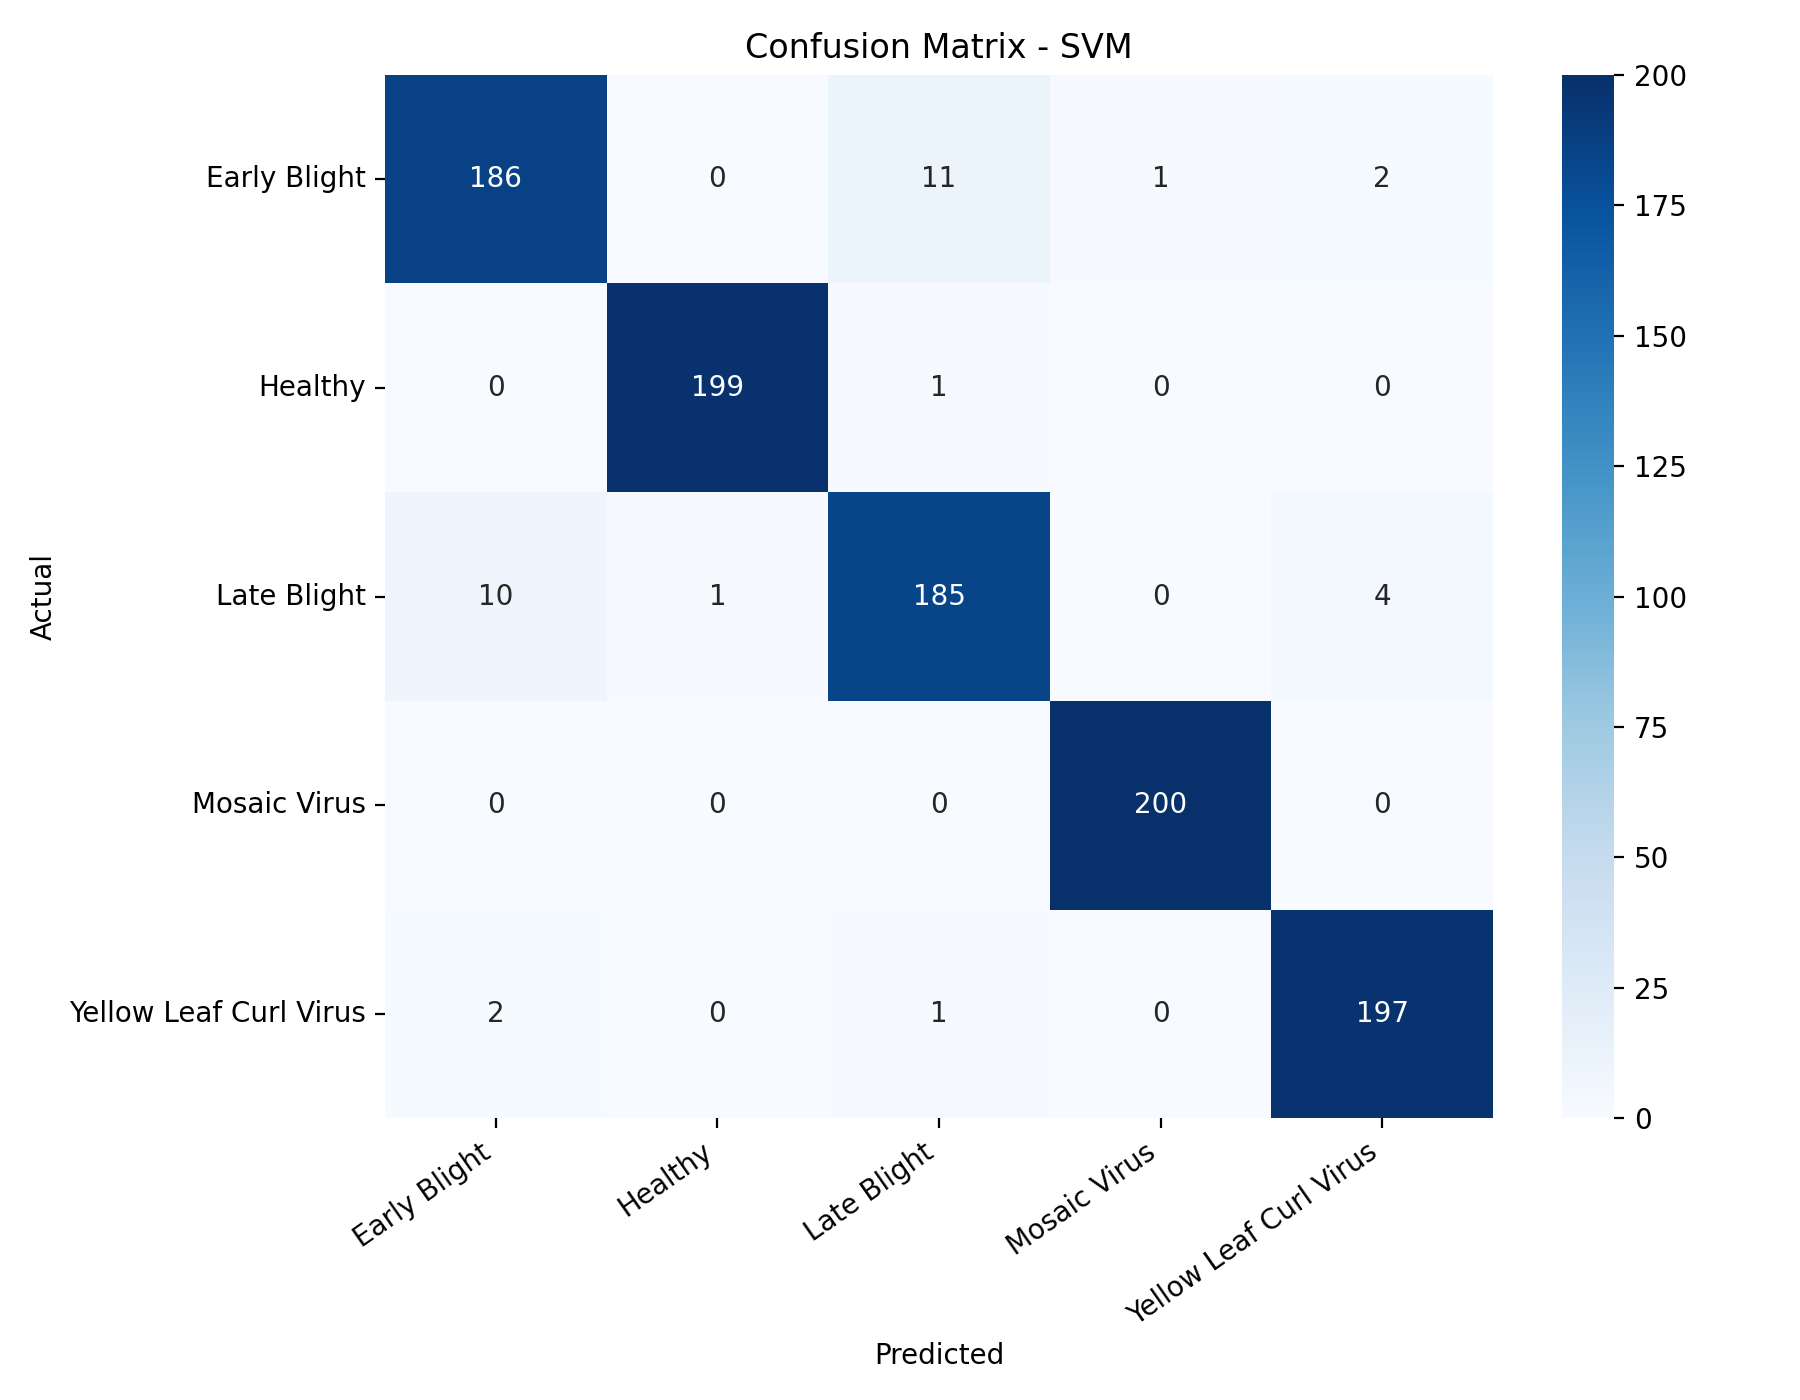

In [16]:
Image(filename=str(PROJECT_ROOT / "reports/figures/confusion_matrix_svm.png"))

### Confusion Matrix KNN

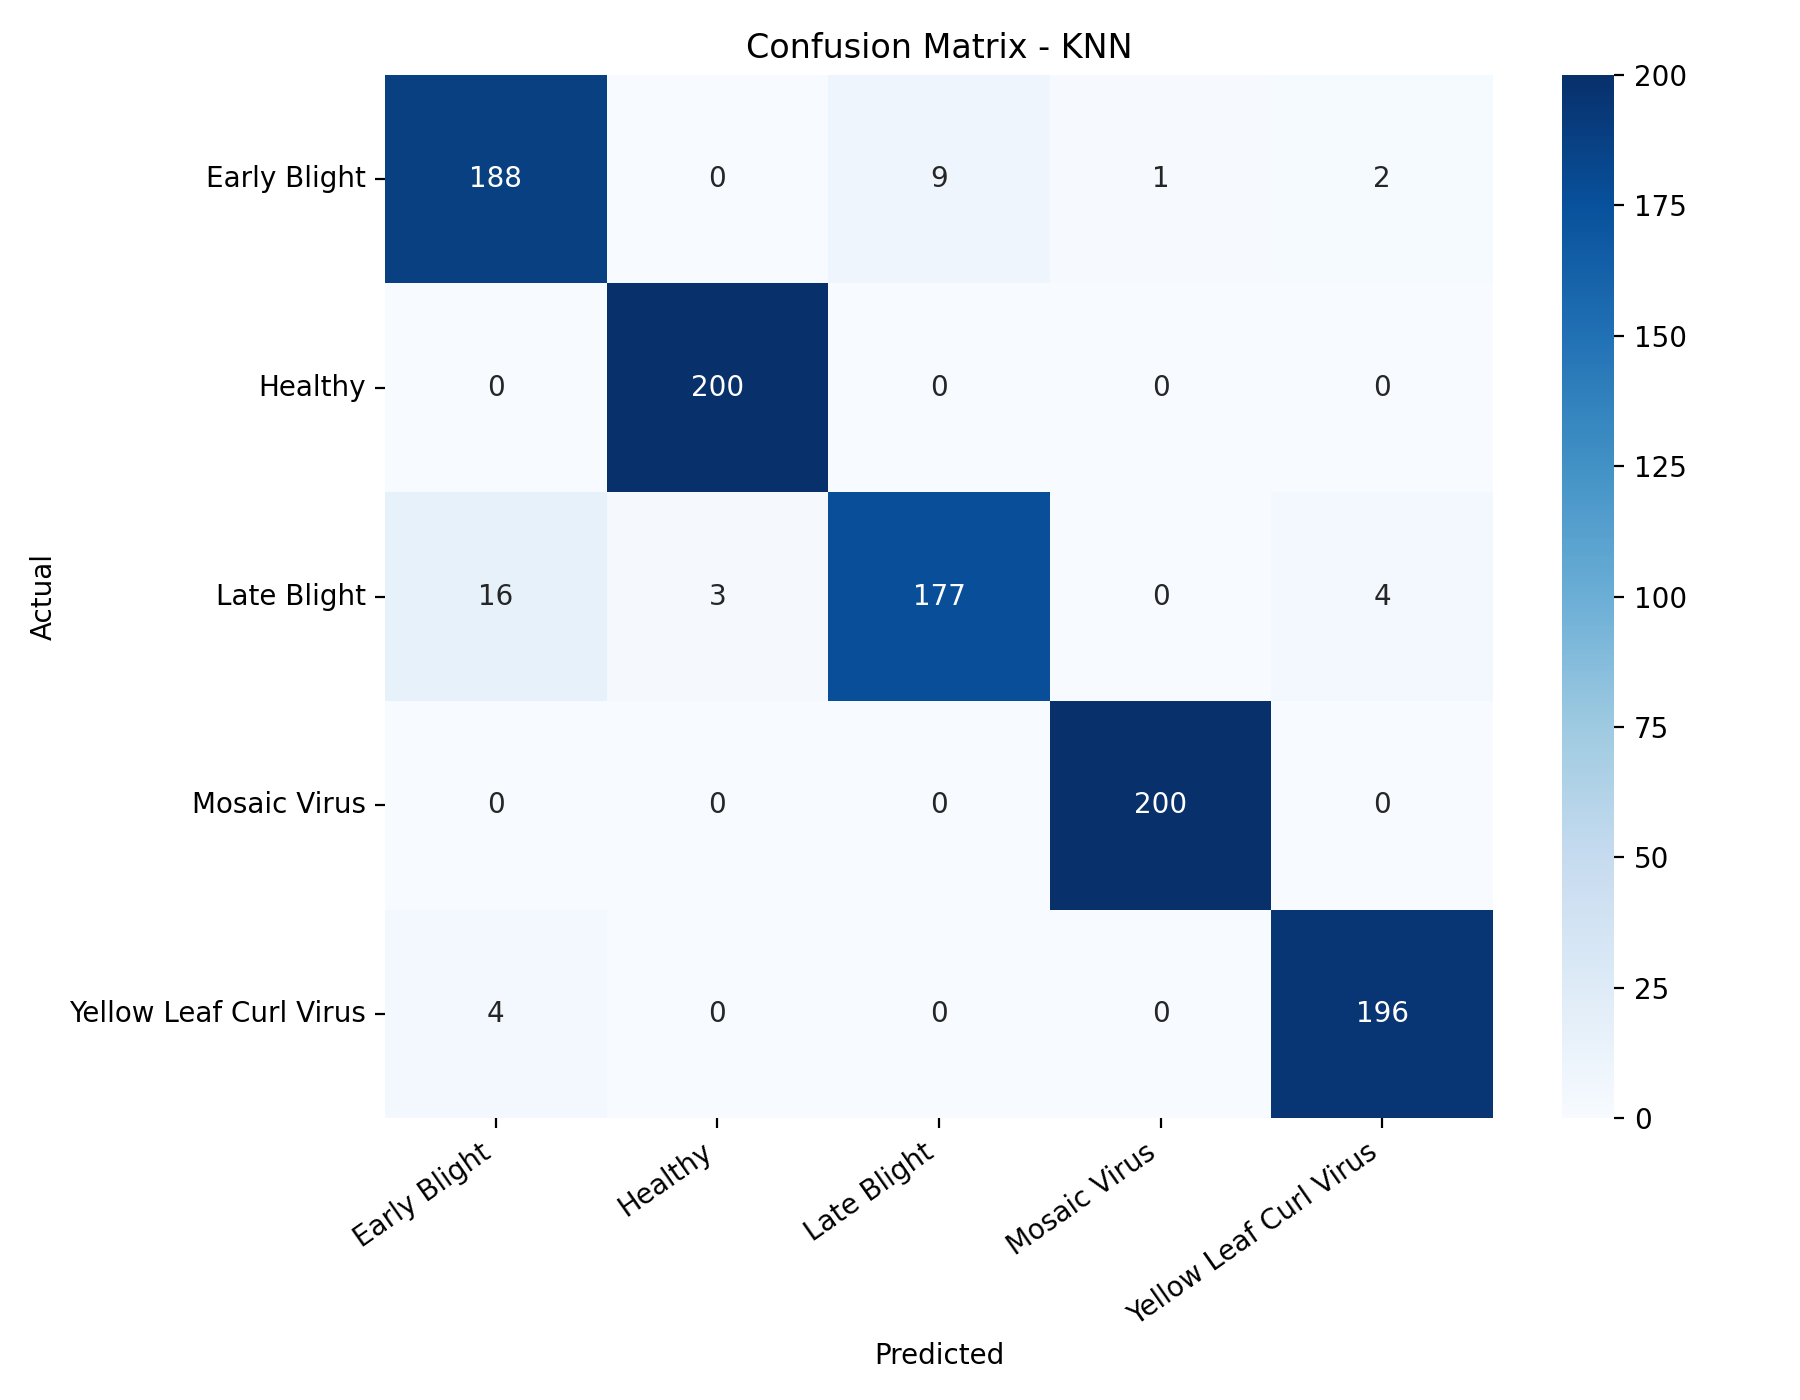

In [17]:
Image(filename=str(PROJECT_ROOT / "reports/figures/confusion_matrix_knn.png"))

## 9. Perbandingan Hasil SVM vs KNN

Tahap ini membuat tabel perbandingan seperti jurnal dan menentukan model terbaik berdasarkan hasil cross validation.

Output:

- `reports/results_summary.md`
- `reports/results_comparison.csv`
- `reports/figures/model_comparison_accuracy.png`
- `reports/figures/model_comparison_precision.png`
- `reports/figures/model_comparison_recall.png`

In [18]:
comparison = compare_results()
comparison

,method,setting,fold,accuracy_mean,precision_macro_mean,recall_macro_mean,f1_macro_mean,auc_ovr_macro_mean
0,SVM,RBF,5,0.96675,0.966993,0.96675,0.966658,0.997554
1,SVM,RBF,10,0.96750,0.967940,0.96750,0.967362,0.997649
2,SVM,RBF,20,0.96850,0.969269,0.96850,0.968407,0.997759
3,KNN,k=5,5,0.95225,0.952311,0.95225,0.951924,0.992759
4,KNN,k=5,10,0.95500,0.955533,0.95500,0.954758,0.993073
5,KNN,k=5,20,0.95500,0.955863,0.95500,0.954734,0.992803


In [19]:
display(Markdown((PROJECT_ROOT / "reports/results_summary.md").read_text(encoding="utf-8")))

# Ringkasan Hasil SVM vs KNN

## Tabel Perbandingan Cross Validation

| K-Fold   |   KNN Accuracy |   KNN Precision |   KNN Recall |   KNN F1 |   SVM Accuracy |   SVM Precision |   SVM Recall |   SVM F1 |
|:---------|---------------:|----------------:|-------------:|---------:|---------------:|----------------:|-------------:|---------:|
| 5-Fold   |         0.9523 |          0.9523 |       0.9523 |   0.9519 |         0.9667 |          0.967  |       0.9667 |   0.9667 |
| 10-Fold  |         0.955  |          0.9555 |       0.955  |   0.9548 |         0.9675 |          0.9679 |       0.9675 |   0.9674 |
| 20-Fold  |         0.955  |          0.9559 |       0.955  |   0.9547 |         0.9685 |          0.9693 |       0.9685 |   0.9684 |

## Hasil Evaluasi Test Set

| model   |   accuracy |   precision_macro |   recall_macro |   f1_macro |   auc_ovr_macro |
|:--------|-----------:|------------------:|---------------:|-----------:|----------------:|
| SVM     |      0.967 |            0.9668 |          0.967 |     0.9669 |          0.997  |
| KNN     |      0.961 |            0.9612 |          0.961 |     0.9608 |          0.9941 |

## Model Terbaik Berdasarkan Cross Validation

Model terbaik berdasarkan rata-rata accuracy adalah **SVM (RBF)**
pada **20-Fold Cross Validation** dengan:

- Accuracy: 0.9685
- Precision macro: 0.9693
- Recall macro: 0.9685
- F1 macro: 0.9684
- AUC OVR macro: 0.9978

## Catatan Interpretasi

Perbandingan utama menggunakan KNN default `k=5`, sesuai rancangan awal. File
`reports/knn_results.csv` tetap menyimpan eksperimen `k=3,5,7,9` untuk analisis tambahan.
Hasil dapat berbeda dari jurnal karena jurnal menggunakan Orange dan tidak menjelaskan detail
ekstraksi fitur citra. Project ini memakai fitur eksplisit RGB histogram, HSV histogram, GLCM, dan LBP.


### Grafik Perbandingan Accuracy

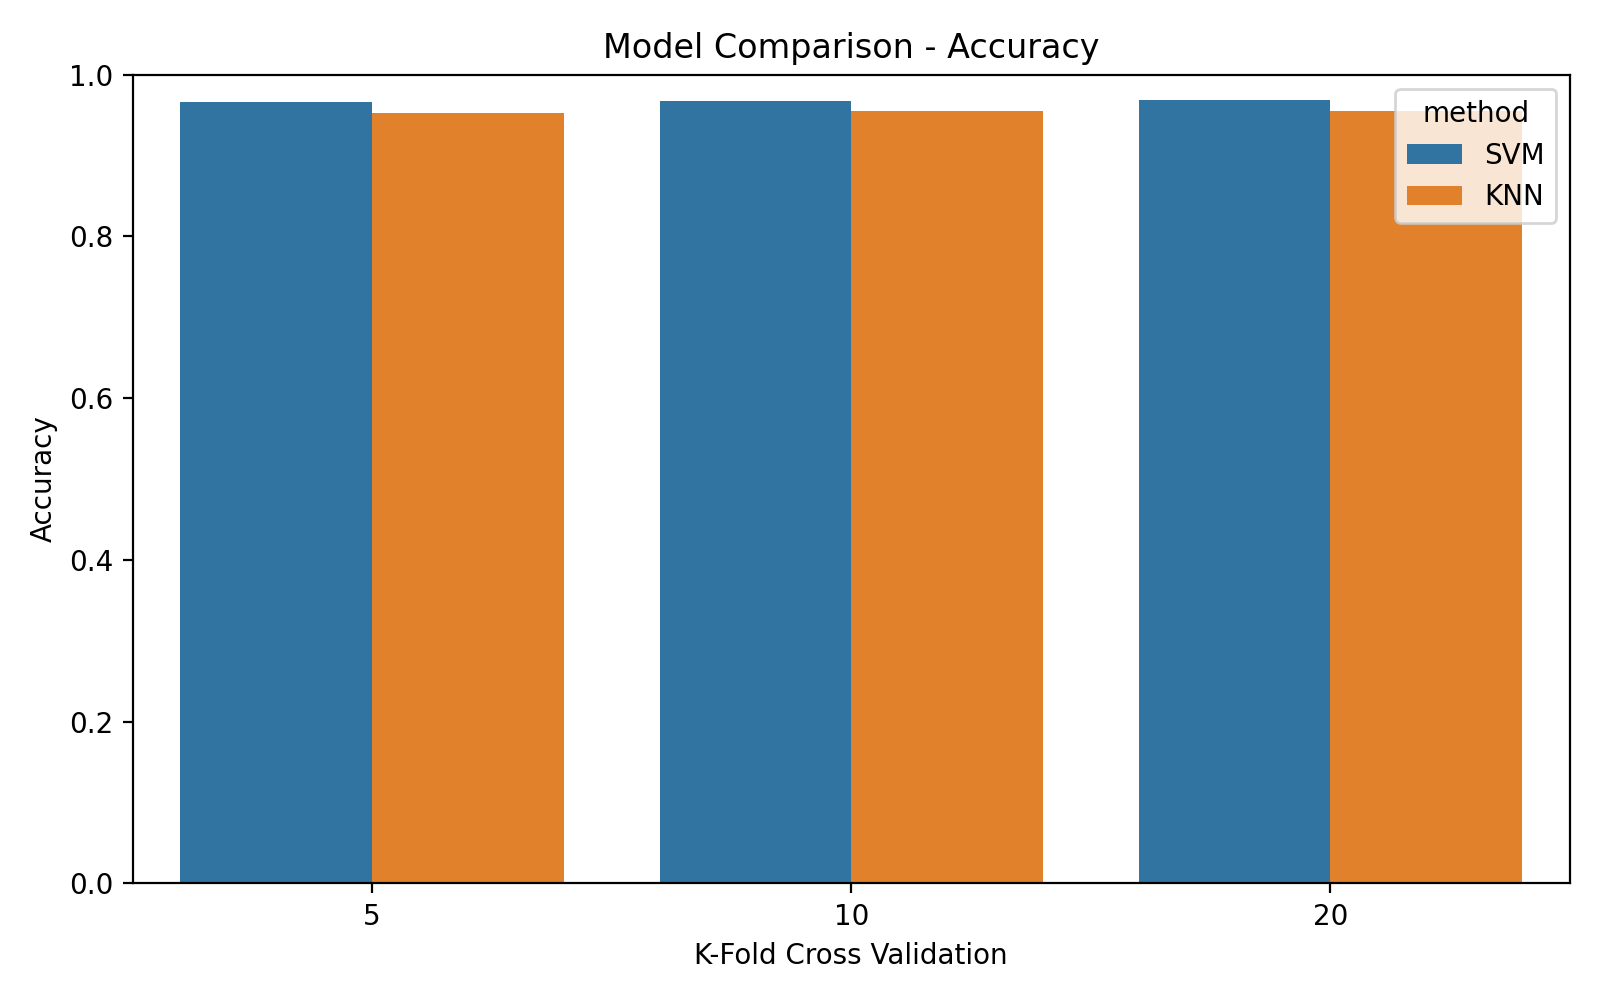

In [20]:
Image(filename=str(PROJECT_ROOT / "reports/figures/model_comparison_accuracy.png"))

### Grafik Perbandingan Precision

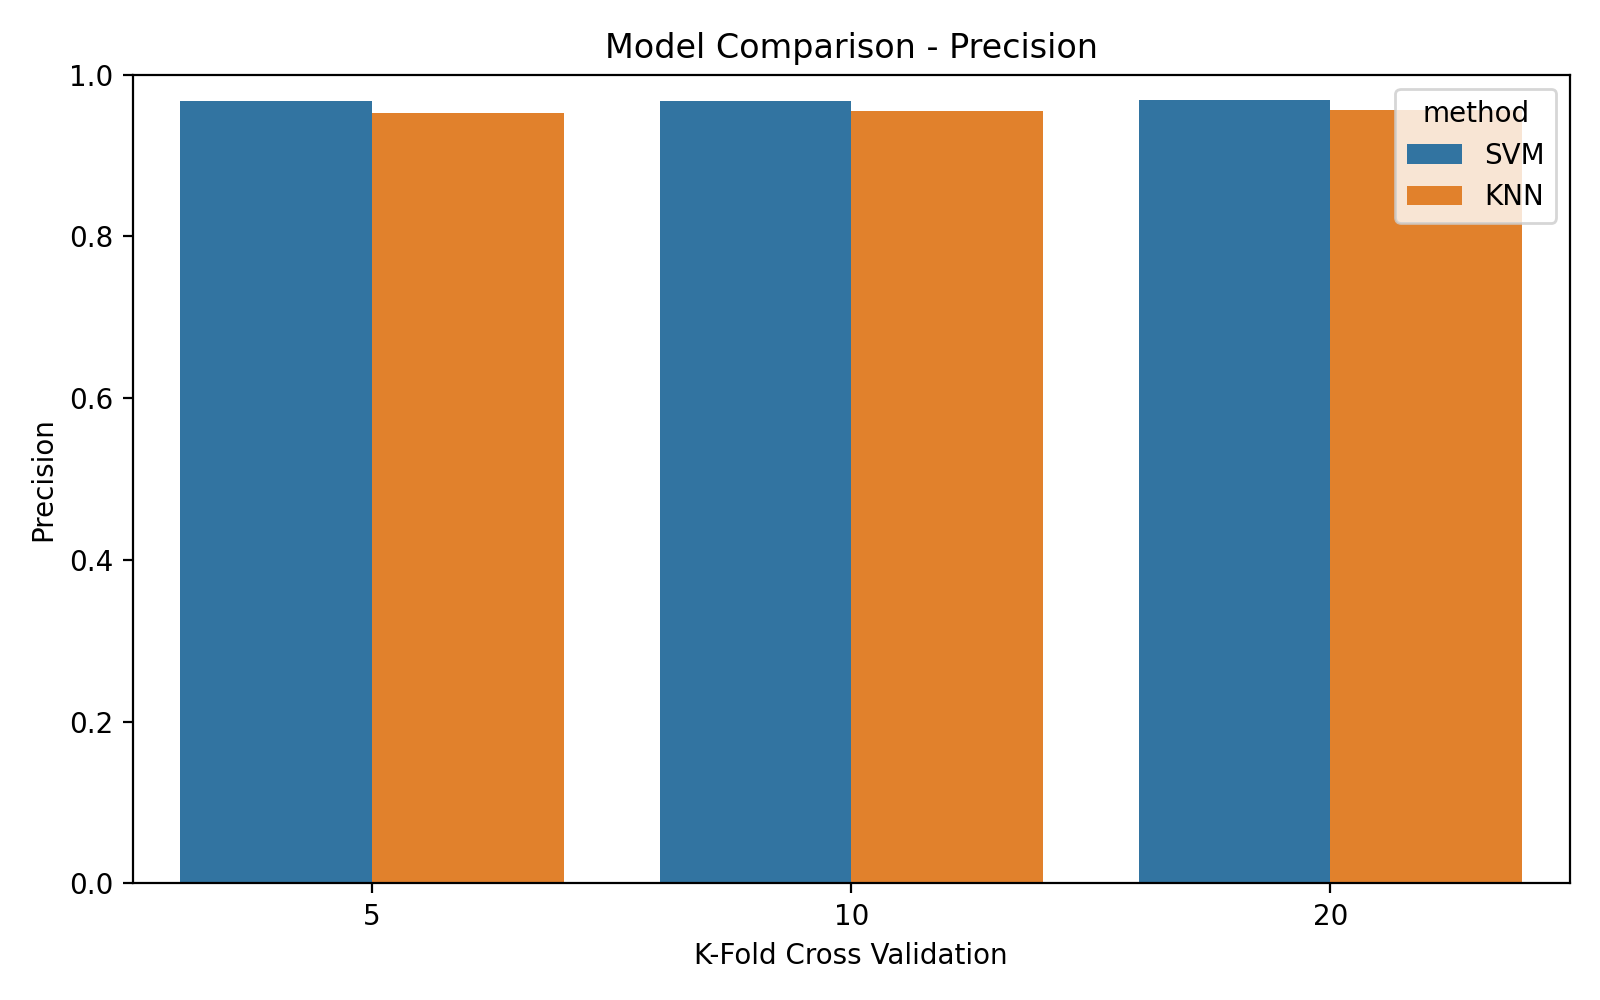

In [21]:
Image(filename=str(PROJECT_ROOT / "reports/figures/model_comparison_precision.png"))

### Grafik Perbandingan Recall

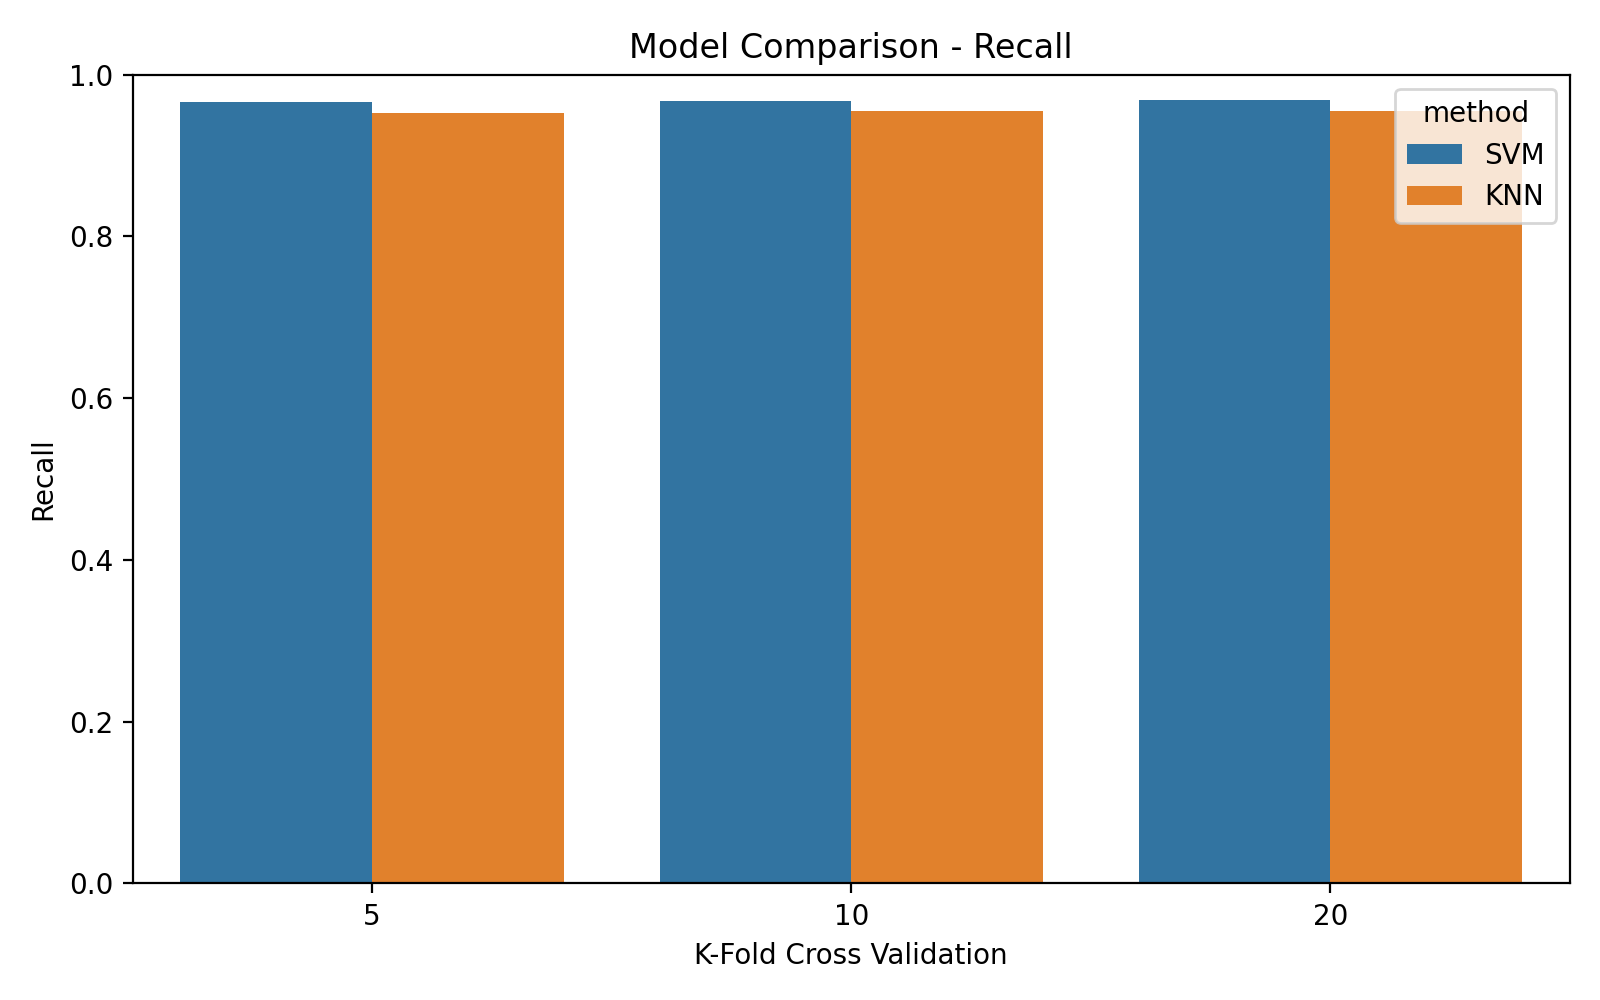

In [22]:
Image(filename=str(PROJECT_ROOT / "reports/figures/model_comparison_recall.png"))

## 10. Kesimpulan Notebook

Notebook ini mengikuti alur replikasi jurnal:

1. Analisis jurnal.
2. Analisis dataset lokal.
3. Preprocessing dan split 80/20.
4. Ekstraksi fitur citra eksplisit.
5. Training SVM dan KNN.
6. Cross validation 5/10/20-Fold.
7. Evaluasi test set.
8. Perbandingan hasil dan kesimpulan model terbaik.

Catatan: hasil bisa berbeda dari jurnal karena jurnal tidak menjelaskan detail preprocessing dan ekstraksi fitur sebelum SVM/KNN.